In [1]:
!pip install spacy bert-score pandas
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.4 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import re
import spacy
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CHEMIN_JSON   = "../data/json/rewrites.json"
CHEMIN_SORTIE = "../data/json/resultats_complets_ner_new.json"

In [ ]:
# nettoyag des réponse du LLM
def nettoyer_texte_llm(texte):
    """
    Nettoie les réponses des LLMs en supprimant les introductions
    et les listes de modifications à la fin.
    """
    if not isinstance(texte, str) or not texte:
        return ""

    texte = texte.strip()

    # Supprimer l'introduction du LLM (préfixe)
    pattern_intro = (
        r"^(?:here(?:'s| is)|sure|certainly|below|this is|as requested|"
        r"of course|absolutely|happy to).*?(?::|\.)\s*\n+"
    )
    texte = re.sub(pattern_intro, "", texte, flags=re.IGNORECASE)

    # Supprimer la conclusion / liste de changements (suffixe)
    pattern_outro = (
        r"(\n\s*(?:i made the following changes|changes made|"
        r"here are the changes|notes?):).*$"
    )
    texte = re.sub(pattern_outro, "", texte, flags=re.IGNORECASE | re.DOTALL)

    return texte.strip()

In [4]:
class ExtracteurFactuel:

    # constantes de classe
    _NER_BLACKLIST  = {'linear', 'minima', 'maxima', 'kernel', 'al.', 'al'}
    _SIGLES_EXCLUS  = {
        'MoCA', 'CaMeLS', 'LLaMa', 'LLaMA',
        'U1', 'U2', 'U3', 'E1', 'E2', 'E3',
        'C1', 'C2', 'C3', 'C4', 'Age2',
    }
    _PATTERN_VAR_SEULE = re.compile(r'^[A-Z]\d{1,2}$')
    _GRECQUES = 'αβγδεζηθικλμνξπρστυφχψωΑΒΓΔΕΖΗΘΙΚΛΜΝΞΠΡΣΤΥΦΧΨΩ'

    def __init__(self):
        print("Chargement du modèle spaCy (en_core_web_sm)...")
        self.nlp = spacy.load("en_core_web_sm")
        print("Modèle chargé !")

    def extraire(self, texte):
        if not texte:
            return {k: set() for k in [
                "Noms_propres", "Mesures", "References",
                "Molecules_chimiques", "Equations",
                "Formules_LaTeX", "Formules"
            ]}

        # noms propres — spaCy + post-filtre

        doc = self.nlp(texte)
        noms_propres = set()
        for ent in doc.ents:
            if ent.label_ not in ["PERSON", "ORG", "GPE", "LOC", "PRODUCT", "WORK_OF_ART"]:
                continue
            t = ent.text.strip()
            if len(t) > 60 or len(t.split()) > 6:
                continue
            if re.search(r'[·\?\!\n\u2019\u201c\u201d]', t):
                continue
            if t and t[0].islower():
                continue
            if t.lower() in self._NER_BLACKLIST:
                continue
            noms_propres.add(t)

        # mesures — unité obligatoire (deux patterns utilisés)

        # unités alphanumériques
        _pat_alpha = (
            r'\b(\d+(?:[.,]\d+)?)\s*'
            r'(mg|kg|µg|g|ml|kHz|MHz|mHz|Hz|kV|mV|ms|µs|mol|mmol|µmol|'
            r'nM|µM|mM|cm|mm|µm|nm|a\.u\.|kDa|Da|rpm|mbar|bar|atm|'
            r'kcal|kJ|eV|keV|MeV|ppm|ppb|ps|ns)\b'
        )
        # unités symboliques
        _pat_sym = (
            r'\b(\d+(?:[.,]\d+)?)\s*'
            r'(%|°C|°F|K|mhz|khz|hz)(?=[\s,\.;\)\n]|$)'
        )
        mesures = set()
        for num, unit in re.findall(_pat_alpha, texte, re.IGNORECASE):
            mesures.add(f"{num} {unit.lower()}")
        for num, unit in re.findall(_pat_sym, texte, re.IGNORECASE):
            mesures.add(f"{num} {unit.lower()}")

        # --------------------------------------------------
        # références bibliographiques
        # --------------------------------------------------
        _pat_ref_paren = (
            r'\([A-Z][a-zA-Z\-]+'
            r'(?:\s+(?:&|and)\s+[A-Z][a-zA-Z\-]+)?'
            r'(?:\s+et\s+al\.?)?'
            r',\s*\d{4}(?:\s*[,;]\s*\d{4})*\)'
        )
        # [1] | [1, 2, 3] | [24,37]
        _pat_ref_croch = r'\[\s*\d+(?:\s*[,;]\s*\d+)*\s*\]'
        references = set(
            re.findall(_pat_ref_paren, texte) +
            re.findall(_pat_ref_croch, texte)
        )

        # --------------------------------------------------
        # molécules chimiques et autres procédés chimiques
        # --------------------------------------------------
        # règle 1 : Majuscule + au moins un chiffre -> H2O, CO2, K562, A549, ..
        _mol_chiffres = r'\b[A-Z][a-zA-Z]*\d+[a-zA-Z0-9]*\b'
        # Règle 2 : 2 éléments collés sans chiffres → NaCl, HCl, FeMo
        _mol_lettres  = (
            r'\b[A-Z][a-z][A-Z][a-z]?\b'
            r'|\b(?:NaCl|HCl|FeMo|MgCl2|TiO2|NaOH|NaHCO3|KCl|CaCl2)\b'
        )
        # règle 3 : formules avec parenthèses -> Ca(OH)2, Fe2(SO4)3, ...
        _mol_paren = (
            r'\b[A-Z][a-z]?\d*'
            r'(?:\([A-Z][a-z]?\d*(?:[A-Z][a-z]?\d*)*\)\d+)+'
            r'(?:[A-Z][a-z]?\d*)*\b'
        )
        molecules = set()
        for m in (re.findall(_mol_chiffres, texte) +
                  re.findall(_mol_lettres,  texte) +
                  re.findall(_mol_paren,    texte)):
            if self._PATTERN_VAR_SEULE.match(m) and m not in {'H2', 'O2', 'N2', 'CO2', 'NO2'}:
                continue
            if m in self._SIGLES_EXCLUS:
                continue
            molecules.add(m)

        # --------------------------------------------------
        # équations compactes (sans espaces, courtes)
        # --------------------------------------------------
        _pat_eq = (
            r'\b([a-zA-Z_]\w{0,15})'
            r'\s*=\s*'
            r'([-+]?[a-zA-Z0-9_\.\^\*\/\(\)]{1,25})'
            r'(?=[\s,;:\.\n\)\]|]|$)'
        )
        equations = set()
        for m in re.finditer(_pat_eq, texte):
            val = m.group(2).strip()
            if re.match(r'^[a-z]{4,}$', val): # rejeter du texte pur
                continue
            equations.add(f"{m.group(1)}={val}")

        # --------------------------------------------------
        # identification des nombres ou quantités
        # --------------------------------------------------
        # cherche uniquement des nombres (entiers, décimaux, ou avec séparateur de milliers)
        pattern_nombres = r'\b\d+(?:[.,]\d+)?\b'
        nombres_trouves = re.findall(pattern_nombres, texte)

        nombres_propres = set()
        for nb in nombres_trouves:
            # sécurité : on nettoie les éventuels espaces ou virgules de fin
            nb_propre = nb.strip()
            nombres_propres.add(nb_propre)

        # --------------------------------------------------
        # montants (Budgets, Prix, Économies)
        # --------------------------------------------------
        # Capture les formats : "$32,000", "$1.24 billion", "500 €", "1.5 million $"
        pattern_montants = r'(?:[\$€£]\s*\d+(?:[.,]\d+)*(?:\s*(?:million|billion|trillion))?|\d+(?:[.,]\d+)*(?:\s*(?:million|billion|trillion))?\s*[\$€£])'

        montants_trouves = re.findall(pattern_montants, texte, re.IGNORECASE)
        montants_propres = set(m.strip() for m in montants_trouves)

        # --------------------------------------------------
        # formules mathématiques et autres
        # --------------------------------------------------
        formules = set()

        # statistiques avec espaces : r = -0.12, p < 0.001, F = 166.51
        _pat_stat = (
            r'\b([a-zA-Z]{1,4})'       # variable courte : r, p, F, b, OR, sHR…
            r'\s*([=<>≤≥])\s*'         # opérateur (avec ou sans espaces)
            r'([-−]?\d+(?:[.,]\d+)?)'  # valeur numérique
        )
        for m in re.finditer(_pat_stat, texte):
            var, op, val = m.group(1), m.group(2), m.group(3)
            # ne pas capturer si une unité de mesure suit immédiatement
            apres = texte[m.end():m.end() + 6]
            if re.match(r'\s*(?:mg|kg|ml|Hz|ms|nm|cm|mm|µ|°)', apres, re.IGNORECASE):
                continue
            formules.add(f"{var} {op} {val}")

        # lettres grecques : σ = 0.3, λ = 1.0, β: 0.249, ΔU > 0.225
        _pat_grec = (
            rf'([{self._GRECQUES}][a-zA-Z₀-₉ⱼ]*)'  # lettre grecque + indice optionnel
            r'\s*(?:_[a-zA-Z])?\s*'                  # indice textuel optionnel
            r'([=:<>≤≥])\s*'
            r'([-−]?\d+(?:[.,]\d+)?)'
        )
        for m in re.finditer(_pat_grec, texte):
            formules.add(f"{m.group(1)} {m.group(2)} {m.group(3)}")

        # plus/minus : 60.0 ± 17.6, 50 ± 18
        _pat_pm = r'(\d+(?:[.,]\d+)?)\s*(?:±|\u2009±\u2009)\s*(\d+(?:[.,]\d+)?)'
        for m in re.finditer(_pat_pm, texte):
            formules.add(f"{m.group(1)} ± {m.group(2)}")

        # notation scientifique : 3 × 10⁻⁸, 1.52 × 10⁶, 2.5×10−5
        _pat_sci = (
            r'(\d+(?:[.,]\d+)?)'
            r'\s*×\s*'
            r'10\s*(?:\^|⁻|−|-)?\s*(\d+)'
        )
        for m in re.finditer(_pat_sci, texte):
            formules.add(f"{m.group(1)} × 10^{m.group(2)}")

        # p-values avec inégalité : p < 0.001, p ≤ 0.05
        _pat_pval = r'\bp\s*([<>≤≥])\s*(0\.\d+)'
        for m in re.finditer(_pat_pval, texte):
            formules.add(f"p {m.group(1)} {m.group(2)}")

        return {
            "Noms_propres":        noms_propres,
            "Mesures":             mesures,
            "References":          references,
            "Molecules_chimiques": molecules,
            "Equations":           equations,
            "Nombres":             nombres_propres,
            "Montants":            montants_propres,
            "Formules":     formules,
        }

# ====================================================================================
# classe de comparaison du paragraphe de base et de la réécriture par le LLM
# ====================================================================================
class ComparateurFactuel:

    def comparer(self, faits_source, faits_generes):
        rapport = {
            "alterations_detectees": False,
            "total_erreurs": 0,
            "details": {}
        }

        for categorie in faits_source.keys():
            source_set  = faits_source[categorie]
            genere_set  = faits_generes[categorie]

            suppressions = source_set - genere_set
            ajouts       = genere_set - source_set
            nb_erreurs   = len(suppressions) + len(ajouts)

            rapport["total_erreurs"] += nb_erreurs
            if nb_erreurs > 0:
                rapport["alterations_detectees"] = True

            rapport["details"][categorie] = {
                "suppressions": list(suppressions),
                "ajouts":       list(ajouts)
            }

        return rapport


# ==========================================
# MODE SCAN — TEST VISUEL (optionnel)
# ==========================================
def scanner_dataset(chemin_json):
    """Affiche les extractions article par article pour vérification visuelle."""
    print("Démarrage du scan...")
    extracteur = ExtracteurFactuel()

    with open(chemin_json, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)

    articles = (raw_data if isinstance(raw_data, list)
                else [a for arts in raw_data.values() for a in arts])
    trouvailles = 0

    for i, article in enumerate(articles):
        for cle in ["Paragraphes", "Paragraphe", "Rew1", "Rew2", "Rew3"]:
            texte_brut = article.get(cle, "")
            if not texte_brut:
                continue

            texte = nettoyer_texte_llm(texte_brut)
            faits = extracteur.extraire(texte)

            if any(faits.values()):
                print(f"\n{'─'*60}")
                print(f"Article {i+1} | Champ : {cle}")
                print(f"{'─'*60}")
                if faits["Noms_propres"]:
                    print(f"Noms propres        : {faits['Noms_propres']}")
                if faits["Mesures"]:
                    print(f"Mesures             : {faits['Mesures']}")
                if faits["References"]:
                    print(f"Références          : {faits['References']}")
                if faits["Molecules_chimiques"]:
                    print(f"Molécules/Cellules  : {faits['Molecules_chimiques']}")
                if faits["Equations"]:
                    print(f"Équations compactes : {faits['Equations']}")
                if faits["Nombres"]:
                    print(f"Nombres               : {faits['Nombres']}")
                if faits["Montants"]:
                    print(f"Montants               : {faits['Montants']}")
                if faits["Formules"]:
                    print(f"Formules     : {faits['Formules']}")
                trouvailles += 1

    print(f"\nScan terminé — {trouvailles} passages pertinents détectés.")


# ====================================================================================
# évaluation complète NER + génération du fichier JSON récapitulatif
# ====================================================================================
def evaluer_et_sauvegarder_json(chemin_entree_json, chemin_sortie_json):
    print("Démarrage de l'évaluation globale...")

    extracteur  = ExtracteurFactuel()
    comparateur = ComparateurFactuel()

    with open(chemin_entree_json, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)

    resultats_finaux   = {}
    articles_a_traiter = []

    if isinstance(raw_data, dict):
        for domaine, articles in raw_data.items():
            articles_a_traiter.extend(articles)
    elif isinstance(raw_data, list):
        articles_a_traiter = raw_data
    else:
        print("Format JSON non reconnu.")
        return

    for article in articles_a_traiter:
        domaine = article.get("Domaine", "Non_specifie")
        if domaine not in resultats_finaux:
            resultats_finaux[domaine] = []

        texte_source = article.get("Paragraphes", article.get("Paragraphe", ""))
        faits_source = extracteur.extraire(texte_source)

        bloc_article = {
            "DOI":        article.get("Doi", article.get("DOI", "N/A")),
            "Texte_source": texte_source,
            "Evaluations": {}
        }

        for rew_key in ["Rew1", "Rew2", "Rew3"]:
            texte_brut = article.get(rew_key, "")
            if not texte_brut:
                continue

            texte_propre   = nettoyer_texte_llm(texte_brut)
            faits_generes  = extracteur.extraire(texte_propre)
            rapport        = comparateur.comparer(faits_source, faits_generes)
            rapport["texte_evalue"] = texte_propre
            bloc_article["Evaluations"][rew_key] = rapport

        resultats_finaux[domaine].append(bloc_article)

    with open(chemin_sortie_json, 'w', encoding='utf-8') as f:
        json.dump(resultats_finaux, f, indent=4, ensure_ascii=False)

    print(f"Évaluation terminée ! Résultats sauvegardés : {chemin_sortie_json}")

if __name__ == "__main__":

    # MODE TEST  — affichage visuel pour vérifier les extractions
    scanner_dataset(CHEMIN_JSON)

    # MODE PRODUCTION — décommenter quand les extractions sont validées
    evaluer_et_sauvegarder_json(CHEMIN_JSON, CHEMIN_SORTIE)

Démarrage du scan...
Chargement du modèle spaCy (en_core_web_sm)...
Modèle chargé !

────────────────────────────────────────────────────────────
Article 1 | Champ : Paragraphes
────────────────────────────────────────────────────────────
Noms propres        : {'Chan et al.', 'News Crawl', 'Wikipedia', 'CommonCrawl', 'Devlin et al.', 'Digitale Bibliothek Münchener Digitalisierungszentrum', 'Struß', 'DBMDZ', 'EU Bookshop', 'ParaCrawl', 'Open Subtitles', 'BERT', 'Transformer'}
Références          : {'(Risch et al., 2021)', '(Chan et al., 2020)', '(Devlin et al., 2018)'}
Nombres               : {'12', '10', '2020', '2018', '2021', '11', '2019'}

────────────────────────────────────────────────────────────
Article 1 | Champ : Rew1
────────────────────────────────────────────────────────────
Noms propres        : {'Chan et al.', 'News Crawl', 'Wikipedia', 'CommonCrawl', 'Devlin et al.', 'Digitale Bibliothek Münchener Digitalisierungszentrum', 'Deepset', 'DBMDZ', 'EU Bookshop', 'ParaCrawl', 

--- BILAN QUANTITATIF GLOBAL ---


,Total erreurs,Textes hallucinés,Taux d'hallucination (%)
Rew1,1137,107,88.43
Rew2,696,80,66.12
Rew3,660,87,71.90


      Total erreurs  Textes hallucinés  Taux d'hallucination (%)
Rew1           1137                107                     88.43
Rew2            696                 80                     66.12
Rew3            660                 87                     71.90

--- VULNÉRABILITÉ PAR TYPE D'ENTITÉ ---


,Rew1,Rew2,Rew3
Noms_propres,252,111,151
Mesures,139,103,70
References,82,51,51
Molecules_chimiques,4,6,5
Equations,82,47,45
Nombres,512,305,293
Montants,1,10,0
Formules,65,63,45


                     Rew1  Rew2  Rew3
Noms_propres          252   111   151
Mesures               139   103    70
References             82    51    51
Molecules_chimiques     4     6     5
Equations              82    47    45
Nombres               512   305   293
Montants                1    10     0
Formules               65    63    45


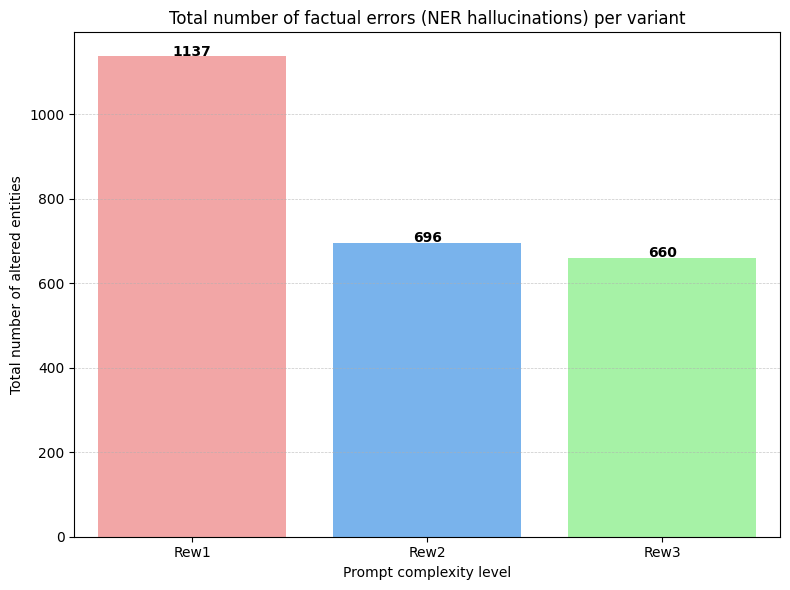

In [20]:
# charger les données du fichier JSON
with open(CHEMIN_SORTIE, 'r', encoding='utf-8') as f:
    data = json.load(f)

# initialisation des dictionnaires pour stocker les statistiques
stats_globales = {
    "Rew1": {"Total erreurs": 0, "Textes hallucinés": 0},
    "Rew2": {"Total erreurs": 0, "Textes hallucinés": 0},
    "Rew3": {"Total erreurs": 0, "Textes hallucinés": 0}
}

# correspondance des clés du JSON
map_rew = {"Rew1": "Rew1", "Rew2": "Rew2", "Rew3": "Rew3"}

erreurs_par_entite = { "Rew1": {}, "Rew2": {}, "Rew3": {} }
total_textes = 0

# parcours du JSON pour extraire les données
for domaine, documents in data.items():
    for doc in documents:
        total_textes += 1
        evals = doc.get("Evaluations", {})

        for rew_key, resultats in evals.items():
            nom_variante = map_rew[rew_key]

            # bilan global
            stats_globales[nom_variante]["Total erreurs"] += resultats.get("total_erreurs", 0)
            if resultats.get("alterations_detectees"):
                stats_globales[nom_variante]["Textes hallucinés"] += 1

            # bilan par type d'entité (nombres, noms propres, etc.)
            details = resultats.get("details", {})
            for type_entite, modifs in details.items():
                # addition des mots supprimés et ajoutés
                nb_erreurs = len(modifs.get("suppressions", [])) + len(modifs.get("ajouts", []))

                if type_entite not in erreurs_par_entite[nom_variante]:
                    erreurs_par_entite[nom_variante][type_entite] = 0
                erreurs_par_entite[nom_variante][type_entite] += nb_erreurs

# affichage du bilan global sous forme de tableau
df_global = pd.DataFrame(stats_globales).T
df_global["Taux d'hallucination (%)"] = ((df_global["Textes hallucinés"] / total_textes) * 100).round(2)
print("--- BILAN QUANTITATIF GLOBAL ---")
display(df_global)
print(df_global)
# préparation des données pour le graphique des entités
df_entites = pd.DataFrame(erreurs_par_entite).fillna(0).astype(int)
print("\n--- VULNÉRABILITÉ PAR TYPE D'ENTITÉ ---")
display(df_entites)
print(df_entites)
# génération du graphique des erreurs globales
plt.figure(figsize=(8, 6))
sns.barplot(x=df_global.index, y=df_global["Total erreurs"], hue=df_global.index, palette=["#ff9999", "#66b3ff", "#99ff99"])
plt.title("Total number of factual errors (NER hallucinations) per variant")
plt.ylabel("Total number of altered entities")
plt.xlabel("Prompt complexity level")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ajouter les valeurs sur les barres
for i, v in enumerate(df_global["Total erreurs"]):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

--- BALANCE ENTRE OMISSIONS ET HALLUCINATIONS ---


,Suppressions,Ajouts
Rew1,1010,127
Rew2,622,74
Rew3,594,66


      Suppressions  Ajouts
Rew1          1010     127
Rew2           622      74
Rew3           594      66


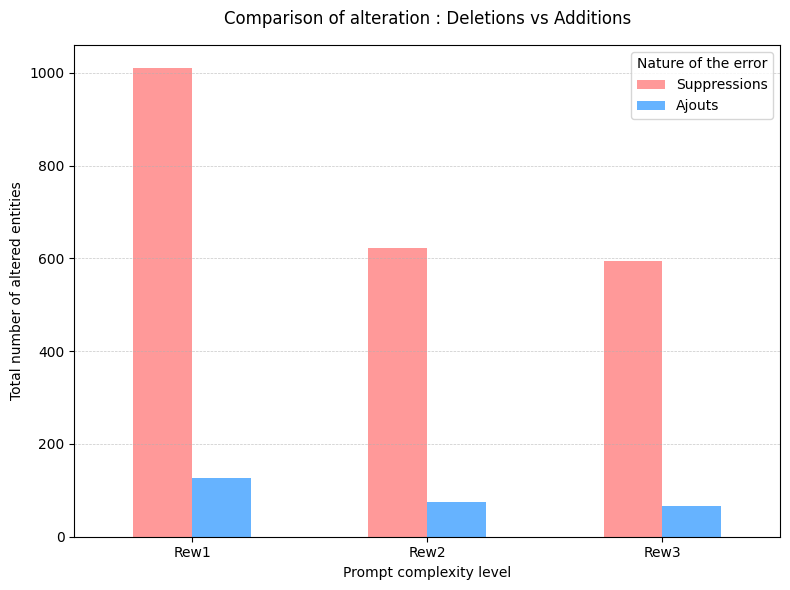


--- EXEMPLES DE MOTS INVENTÉS (AJOUTS) PAR L'IA ---


,Variante,Type,Mot inventé
192,Rew2,Equations,deviation=8.5
207,Rew3,Formules,P < 0.001
46,Rew2,Mesures,2.5 %
254,Rew2,Montants,$1.24 trillion
162,Rew2,Nombres,1
132,Rew2,Noms_propres,Bragg
138,Rew1,References,[1]



--- EXEMPLES DE MOTS OUBLIÉS (SUPPRESSIONS) PAR L'IA ---


,Variante,Type,Mot supprimé
554,Rew3,Equations,n=101
1178,Rew2,Formules,2.5 × 10^5
1647,Rew3,Mesures,10 μg
704,Rew3,Molecules_chimiques,S105
2153,Rew2,Montants,$7.2692 billion
1905,Rew2,Nombres,0.68
1127,Rew1,Noms_propres,Tedder
822,Rew1,References,[87]


In [25]:
# charger les données
with open(CHEMIN_SORTIE, 'r', encoding='utf-8') as f:
    data = json.load(f)

# dictionnaires pour stocker les statistiques fines
stats_fines = {
    "Rew1": {"Suppressions": 0, "Ajouts": 0},
    "Rew2": {"Suppressions": 0, "Ajouts": 0},
    "Rew3": {"Suppressions": 0, "Ajouts": 0}
}
map_rew = {"Rew1": "Rew1", "Rew2": "Rew2", "Rew3": "Rew3"}

# listes pour stocker des exemples qualitatifs aléatoires
exemples_ajouts = []
exemples_suppressions = []

# parcours du JSON
for domaine, documents in data.items():
    for doc in documents:
        evals = doc.get("Evaluations", {})
        for rew_key, resultats in evals.items():
            nom_variante = map_rew[rew_key]
            details = resultats.get("details", {})

            for type_entite, modifs in details.items():
                sups = modifs.get("suppressions", [])
                ajs = modifs.get("ajouts", [])

                # comptage global
                stats_fines[nom_variante]["Suppressions"] += len(sups)
                stats_fines[nom_variante]["Ajouts"] += len(ajs)

                # récolte des mots exacts (pour l'étude de cas)
                for s in sups:
                    exemples_suppressions.append({"Variante": nom_variante, "Type": type_entite, "Mot supprimé": s})
                for a in ajs:
                    exemples_ajouts.append({"Variante": nom_variante, "Type": type_entite, "Mot inventé": a})

# affichage du tableau de bord
df_fines = pd.DataFrame(stats_fines).T
print("--- BALANCE ENTRE OMISSIONS ET HALLUCINATIONS ---")
display(df_fines)
print(df_fines)
df_fines.plot(kind='bar', stacked=False, figsize=(8, 6), color=['#ff9999', '#66b3ff'])

plt.title("Comparison of alteration : Deletions vs Additions", pad=15)
plt.ylabel("Total number of altered entities")
plt.xlabel("Prompt complexity level")
plt.xticks(rotation=0)
plt.legend(title="Nature of the error", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# affichage de quelques exemples réels
print("\n--- EXEMPLES DE MOTS INVENTÉS (AJOUTS) PAR L'IA ---")
df_ajouts = pd.DataFrame(exemples_ajouts)
if not df_ajouts.empty:
    echantillon_ajouts = df_ajouts.groupby('Type').sample(n=1)
    display(echantillon_ajouts)
else:
    print("Aucun ajout détecté.")

print("\n--- EXEMPLES DE MOTS OUBLIÉS (SUPPRESSIONS) PAR L'IA ---")
df_suppressions = pd.DataFrame(exemples_suppressions)
if not df_suppressions.empty:
    echantillon_suppressions = df_suppressions.groupby('Type').sample(n=1)
    display(echantillon_suppressions)
else:
    print("Aucune suppression détectée")

--- TOTAL DES ERREURS PAR DOMAINE ET PAR PROMPT ---


Variante,Rew1,Rew2,Rew3
Domaine,,,
CHEMICAL,178,164,145
COMPUTER SCIENCE,206,104,91
ECONOMICS FINANCE,122,63,28
HEALTH,270,162,173
STATISTICS,206,115,122
TALN,155,88,101


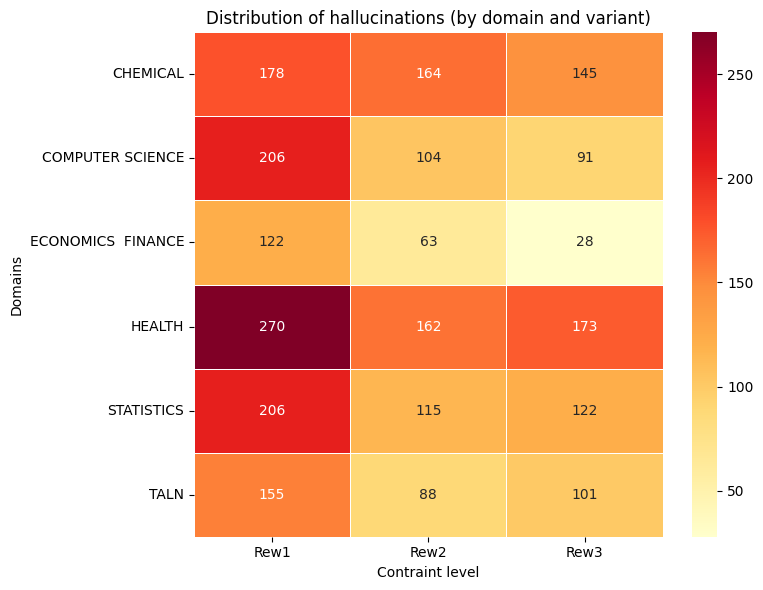

In [23]:
# charger les données
with open(CHEMIN_SORTIE, 'r', encoding='utf-8') as f:
    data = json.load(f)

map_rew = {"Rew1": "Rew1", "Rew2": "Rew2", "Rew3": "Rew3"}
erreurs_domaine = []

# parcours du JSON pour croiser Domaine et Variante
for domaine, documents in data.items():
    for doc in documents:
        evals = doc.get("Evaluations", {})
        for rew_key, resultats in evals.items():
            nom_variante = map_rew[rew_key]
            nb_erreurs = resultats.get("total_erreurs", 0)

            erreurs_domaine.append({
                "Domaine": domaine,
                "Variante": nom_variante,
                "Erreurs": nb_erreurs
            })

# création du DataFrame et tableau croisé dynamique
df_domaines = pd.DataFrame(erreurs_domaine)
pivot_domaines = df_domaines.pivot_table(
    values='Erreurs',
    index='Domaine',
    columns='Variante',
    aggfunc='sum' # sommation des erreurs par domaine et par prompt
)

print("--- TOTAL DES ERREURS PAR DOMAINE ET PAR PROMPT ---")
display(pivot_domaines)
# génération d'une Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_domaines, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)
plt.title("Distribution of hallucinations (by domain and variant)")
plt.ylabel("Domains")
plt.xlabel("Contraint level")
plt.tight_layout()
plt.show()

--- SCORE FACT_ACC (Taux de réécritures parfaites) ---
Variante Réécriture 1 : 11.57% de perfection factuelle
Variante Réécriture 2 : 33.88% de perfection factuelle
Variante Réécriture 3 : 28.10% de perfection factuelle


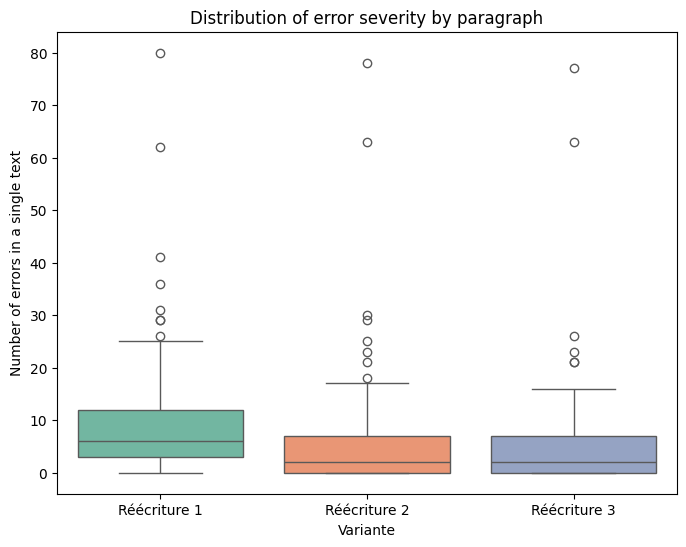

In [26]:
with open(CHEMIN_SORTIE, 'r', encoding='utf-8') as f:
    data = json.load(f)

map_rew = {"Rew1": "Réécriture 1", "Rew2": "Réécriture 2", "Rew3": "Réécriture 3"}
fact_acc_data = {"Réécriture 1": 0, "Réécriture 2": 0, "Réécriture 3": 0}
distribution_erreurs = []
total_textes = 0

for domaine, documents in data.items():
    total_textes += len(documents)
    for doc in documents:
        evals = doc.get("Evaluations", {})
        for rew_key, resultats in evals.items():
            nom_variante = map_rew[rew_key]
            nb_erreurs = resultats.get("total_erreurs", 0)

            # calcul de la distribution
            distribution_erreurs.append({"Variante": nom_variante, "Erreurs": nb_erreurs})

            # calcul du fact_acc (Textes avec ZÉRO erreur)
            if not resultats.get("alterations_detectees"):
                fact_acc_data[nom_variante] += 1

print("--- SCORE FACT_ACC (Taux de réécritures parfaites) ---")
for var, succes in fact_acc_data.items():
    score = (succes / total_textes) * 100
    print(f"Variante {var} : {score:.2f}% de perfection factuelle")

# --- affichage du Boxplot ---
df_dist = pd.DataFrame(distribution_erreurs)
plt.figure(figsize=(8, 6))
sns.boxplot(x="Variante", y="Erreurs", data=df_dist, hue="Variante", palette="Set2", legend=False)
plt.title("Distribution of error severity by paragraph")
plt.ylabel("Number of errors in a single text")
plt.show()